In [ ]:
import pandas as pd

afs_data = pd.read_csv('afs_dist.csv')
afs_data.head()

,Country,Survey,Women 8,Women 9,Women 10,Women 11,Women 12,Women 13,Women 14,Women 15,...,Men 9,Men 10,Men 11,Men 12,Men 13,Men 14,Men 15,Men 16,Men 18,Men 20
0,Zambia,2018 DHS + Sakas et al. 2024,0.07000,0.10000,0.23,0.64,2.440,6.25,16.54,36.08,...,0.64,1.87,2.48,5.78,7.68,12.83,25.39,34.79,56.71,71.41
1,Zambia Western,2018 DHS + Sakas et al. 2024,0.00001,0.00002,0.09,0.55,3.010,12.50,28.38,53.10,...,1.63,4.43,5.94,12.35,16.55,27.04,45.45,55.59,73.89,85.31
2,Zambia Luapula,2018 DHS Sakas et al. 2024,0.07000,0.07000,0.42,1.20,3.470,7.57,15.84,34.72,...,1.12,3.28,3.92,7.20,8.64,11.64,23.04,31.68,56.24,73.60
3,Zambia Ultra High Risk,2018 DHS + Sakas et al. 2024,0.10500,0.10500,0.63,1.80,5.205,18.75,42.57,79.65,...,1.63,4.43,5.94,12.35,16.55,27.04,45.45,55.59,73.89,85.31
4,Cote d'Ivoire,2021 DHS,0.06000,0.10000,0.50,1.32,3.220,7.62,18.66,38.20,...,0.08,0.42,0.96,1.77,2.86,5.86,12.09,19.31,40.55,60.51


In [2]:
# Filter for the row where Country is 'Zambia'
zambia_row = afs_data[afs_data['Country'] == 'Zambia']

# Select columns that start with 'Women'
women_cols = [col for col in zambia_row.columns if col.startswith('Women')]

# Extract the ages from the column names
ages = [int(col.split()[1]) for col in women_cols]

# Get the values for Zambia and convert to float
values = zambia_row[women_cols].iloc[0].astype(float).values

# Construct S(a) = 1 - value/100
S_a = 1 - values / 100

# S(a) is now a numpy array, and ages is a list of corresponding ages
print("Ages:", ages)
print("S(a):", S_a)

Ages: [8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 20]
S(a): [0.9993 0.999  0.9977 0.9936 0.9756 0.9375 0.8346 0.6392 0.4793 0.27
 0.181 ]


In [6]:
import numpy as np

def impact_function(C, A, N):
    """
    Computes the impact function:
    C * sum(S(a) from A to A+N) / (N+1)
    where S(a) is defined for the ages in the 'ages' list.

    Parameters:
        C (float): A constant between 0 and 1.
        A (int): Initial age.
        N (int): Number of years to sum over.

    Returns:
        float: The computed impact value.
    """
    # Find the indices in 'ages' corresponding to A and A+N
    try:
        start_idx = ages.index(A)
        end_idx = ages.index(A + N)
    except ValueError:
        raise ValueError("A or A+N not found in ages list.")

    S_sum = S_a[start_idx:end_idx + 1].sum()
    return C * S_sum / (N + 1)

    

In [ ]:
import matplotlib.pyplot as plt
def plot_impact_ratio_heatmap(A, N0, N1):
    """
    Plots a heatmap of the ratio of the impact function for two different N values at age A.

    Parameters:
        A (int): Initial age.
        N0 (int): First N value.
        N1 (int): Second N value.
    """
    # Define ranges for C values
    C_values = np.linspace(0.10, 0.9, 100)

    # Prepare a grid for C0 (for N=N0) and C1 (for N=N1)
    C0_grid, C1_grid = np.meshgrid(C_values, C_values)

    # Compute impact for N=N0 and N=N1 at A
    impact_N0 = np.vectorize(lambda C: impact_function(C, A, N0))(C0_grid)
    impact_N1 = np.vectorize(lambda C: impact_function(C, A, N1))(C1_grid)

    # Compute the ratio
    ratio = impact_N0 / impact_N1

    # Plot heatmap
    plt.figure(figsize=(8, 6))
    im = plt.imshow(
        np.log10(ratio),
        extent=[0.1, 0.9, 0.1, 0.9],
        origin='lower',
        aspect='auto',
        cmap='seismic',
        vmin=-np.abs(np.log10(ratio)).max(),
        vmax=np.abs(np.log10(ratio)).max(),
    )

    # Create colorbar with custom tick labels in linear space (impact ratio)
    cbar = plt.colorbar(im, label='Impact Ratio N={} / N={}'.format(N0, N1))
    linear_ticks = np.array([0.2, 0.5, 1, 2, 5])
    log_ticks = np.log10(linear_ticks)
    cbar.set_ticks(log_ticks)
    cbar.set_ticklabels([str(v) for v in linear_ticks])

    # Highlight where np.log10(ratio) == 0 (i.e., ratio == 1)
    zero_mask = np.isclose(np.log10(ratio), 0, atol=2e-2)
    ys, xs = np.where(zero_mask)
    plt.scatter(
        C_values[xs], C_values[ys],
        color='green', s=10, label='log10(ratio)=0'
    )
    plt.legend(loc='upper right')
    plt.xlabel(f'C for N={N1}')
    plt.ylabel(f'C for N={N0}')
    plt.title(f'Heatmap of Impact Function Ratio\n(A={A}, N={N0} vs. A={A}, N={N1})')
    plt.show()

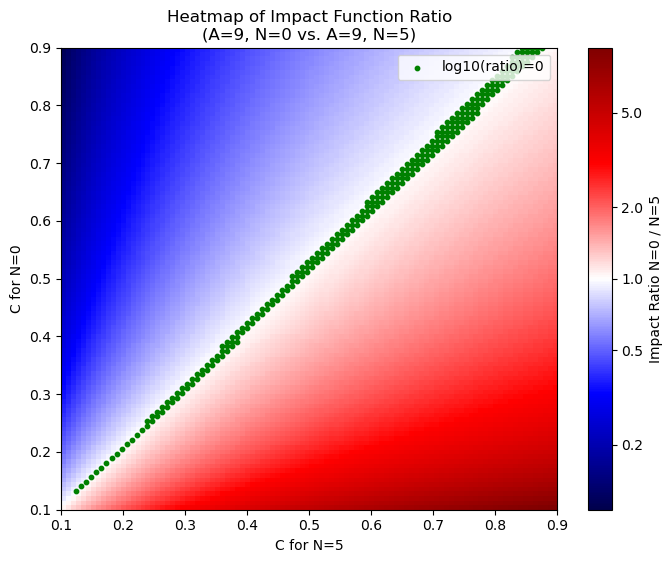

In [46]:
plot_impact_ratio_heatmap(9, 0, 5)

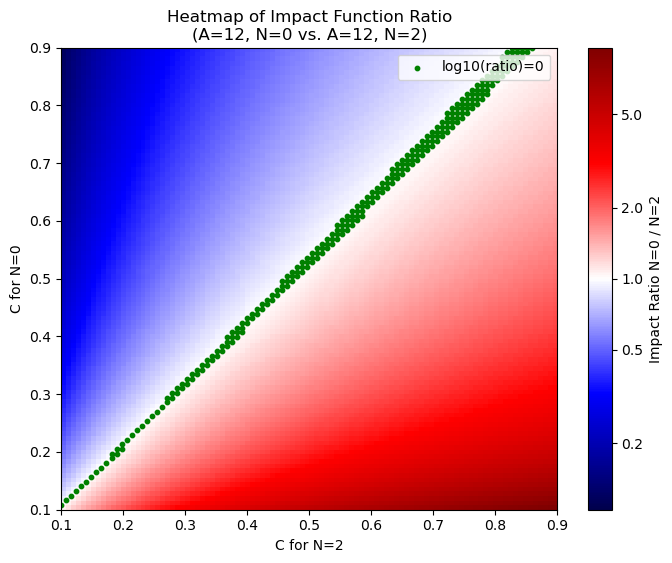

In [45]:
plot_impact_ratio_heatmap(12, 0, 2)